### [이미지 내 객체의 윤곽선/외곽선 추출 : 컨투어 ] <hr>
- 윤곽선/외곽선에 해당하는 좌표값(즉, 픽셀들) 반환
- 좌표 개수를 줄이기 위한 매개변수 설정 필요 ===> 메모리 / 연산 고려

In [1]:
import cv2
import numpy as np
import sys
sys.path.append('..')
from cv_utils import *

area: 9870.00
area: 12544.00
area: 6216.00


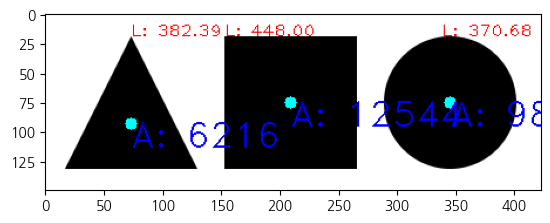

In [13]:
img = cv2.imread('../Data/images/shapes.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

ret, th = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

contours, hierachy = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[-2:]

for c in contours:
    mmt = cv2.moments(c)

    cx = int(mmt['m10']/mmt['m00'])
    cy = int(mmt['m01']/mmt['m00'])

    a = mmt['m00']

    l = cv2.arcLength(c,True)

    cv2.circle(img, (cx, cy), 5, (0,255,255), -1)

    cv2.putText(img, f"A: {a:.0f}", (cx, cy+20), cv2.FONT_HERSHEY_DUPLEX, 1, (0,0,255))
    cv2.putText(img, f"L: {l:.2f}", tuple(c[0][0]), cv2.FONT_HERSHEY_PLAIN, 1, (255,0,0))

    print(f'area: {cv2.contourArea(c, False):.2f}')

plt.imshow(img)